In [ ]:
import pandas as pd

dataset = pd.read_csv('/content/drive/MyDrive/Data Mining Lab/Airbnb_new.csv')
print(dataset.info())
dataset.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   46520                    1000 non-null   int64  
 1   Last year reviews        1000 non-null   int64  
 2   Host since               1000 non-null   object 
 3   Host is superhost        1000 non-null   object 
 4   Host number of listings  1000 non-null   int64  
 5   Neighbourhood            1000 non-null   object 
 6   Beds number              1000 non-null   int64  
 7   Bedrooms number          982 non-null    float64
 8   Property type            1000 non-null   object 
 9   Maximum allowed guests   987 non-null    float64
 10  Price                    996 non-null    float64
 11  Total reviews            1000 non-null   int64  
 12  Rating score             1000 non-null   float64
 13  Accuracy score           1000 non-null   float64
 14  Cleanliness score        

,46520,Last year reviews,Host since,Host is superhost,Host number of listings,Neighbourhood,Beds number,Bedrooms number,Property type,Maximum allowed guests,...,Communication score,Location score,Value for money score,Reviews per month,City,Season,Bathrooms number,Bathrooms type,Coordinates,Date of scraping
0,31840,6,2011-02-07,Host,44,Centro Storico,1,1.0,Private room,2.0,...,4.91,4.91,4.70,0.78,Firenze,Early Winter,1,private,"43.77709, 11.25216",2024-12-15
1,222527,0,2011-07-11,Superhost,3,Rifredi,3,2.0,Entire home,4.0,...,4.96,4.60,4.86,1.92,Firenze,Early Winter,1,private,"43.82005, 11.22004",2024-12-15
2,32120,6,2010-03-26,Host,1,Gavinana Galluzzo,1,1.0,Entire home,2.0,...,4.96,4.63,4.63,0.16,Firenze,Summer,1,private,"43.76157, 11.27741",2024-12-15
3,224562,9,2011-09-16,Host,2,Centro Storico,1,1.0,Entire home,4.0,...,4.83,4.93,4.64,0.71,Firenze,Early Winter,1,private,"43.772, 11.26142",2024-12-15
4,32180,11,2014-04-05,Superhost,1,Centro Storico,4,NaN,Entire home,4.0,...,4.71,4.81,4.84,0.21,Firenze,Early Winter,2,private,"43.76832, 11.24348",2024-12-15


# 1. Fix missing data

a) Apply KNN imputation to fill the missing "Bedrooms number" field. Use fields Beds number and Maximum allowed guests as features and consider k=5

b) Use Mean imputation to fill in the missing "Maximum allowed guests"

c) Apply Regression imputation to fill the missing prices. Use the Neighborhood, property type, number of bedrooms as the features

In [ ]:
import math
from collections import Counter
import pandas as pd

class KnnImputer:
    def __init__(self, k, target_col, feature_cols):
        self.k = k
        self.target_col = target_col          # column to impute
        self.feature_cols = feature_cols      # columns used for distance

    def euclidean_distance(self, p1, p2):
        return math.sqrt(sum((a - b)**2 for a, b in zip(p1, p2)))

    def fit_transform(self, df):
        df = df.copy()

        for i in range(len(df)):
            if pd.isna(df.loc[df.index[i], self.target_col]):
                distances = []

                for j in range(len(df)):
                    if not pd.isna(df.loc[df.index[j], self.target_col]):

                        p1 = df.loc[df.index[i], self.feature_cols].values
                        p2 = df.loc[df.index[j], self.feature_cols].values

                        # Skip if any feature is NaN
                        if pd.isna(p1).any() or pd.isna(p2).any():
                            continue

                        dist = self.euclidean_distance(p1, p2)
                        distances.append((dist, df.loc[df.index[j], self.target_col]))

                distances.sort(key=lambda x: x[0])
                k_neighbors = distances[:self.k]
                values = [val for _, val in k_neighbors]

                df.loc[df.index[i], self.target_col] = Counter(values).most_common(1)[0][0]

        return df


imputer = KnnImputer(
    k=5,
    target_col='Bedrooms number',
    feature_cols=['Beds number', 'Maximum allowed guests']
)
dataset = imputer.fit_transform(dataset)
print("\nAfter KNN imputation on Bedrooms number:")
print(dataset['Bedrooms number'])


After KNN imputation on Bedrooms number:
0      1.0
1      2.0
2      1.0
3      1.0
4      2.0
      ... 
995    3.0
996    1.0
997    1.0
998    1.0
999    1.0
Name: Bedrooms number, Length: 1000, dtype: float64


In [ ]:
import numpy as np
import math

class MeanImputer:
    def __init__(self, column, round_up=False):
        self.column = column
        self.mean_value = None
        self.round_up = round_up

    def fit_transform(self, df):
        values = df[self.column].dropna()
        self.mean_value = values.mean()
        if self.round_up:
            self.mean_value = math.ceil(self.mean_value)
        df[self.column] = df[self.column].fillna(self.mean_value)
        return df


imputer = MeanImputer(column="Maximum allowed guests", round_up=True)

dataset = imputer.fit_transform(dataset)

print("Mean value:", imputer.mean_value)
print("\nAfter Mean imputation on Maximum allowed guests:")
print(dataset["Maximum allowed guests"])

Mean value: 4

After Mean imputation on Maximum allowed guests:
0      2.0
1      4.0
2      2.0
3      4.0
4      4.0
      ... 
995    8.0
996    3.0
997    2.0
998    4.0
999    1.0
Name: Maximum allowed guests, Length: 1000, dtype: float64


In [ ]:
# regression imputation

from sklearn.linear_model import LinearRegression
import pandas as pd
from sklearn.preprocessing import OneHotEncoder


encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded = encoder.fit_transform(dataset[['Neighbourhood', 'Property type']])
df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['Neighbourhood','Property type']),
    index=data.index
)
df = pd.concat([dataset[['Price', 'Bedrooms number']], df], axis=1)

# Separate known and missing for training linear regression
known = df[df["Price"].notna()]
missing = df[df["Price"].isna()]

X_train = known.drop(columns=["Price"])
y_train = known["Price"]

X_pred = missing.drop(columns=["Price"])

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict missing prices
predicted_prices = model.predict(X_pred)

dataset.loc[missing.index, "Price"] = predicted_prices

print("After Regression Imputation on Price:")
print(dataset)

After Regression Imputation on Price:
       46520  Last year reviews  Host since Host is superhost  \
0      31840                  6  2011-02-07              Host   
1     222527                  0  2011-07-11         Superhost   
2      32120                  6  2010-03-26              Host   
3     224562                  9  2011-09-16              Host   
4      32180                 11  2014-04-05         Superhost   
..       ...                ...         ...               ...   
995  4375536                  8  2014-10-19         Superhost   
996  4953441                  2  2013-10-03              Host   
997  4961760                  9  2015-01-04         Superhost   
998  4962982                  4  2015-01-04              Host   
999  4964080                 59  2014-11-26         Superhost   

     Host number of listings      Neighbourhood  Beds number  Bedrooms number  \
0                         44     Centro Storico            1              1.0   
1                  

# 2. Outlier Analysis
a) Identify any price outliers and cap them at 1500, if they go beyond Q3+1.5*IQR and at 10 if they go below Q1-1.5*IQR

b) List down all the outliers based on z-scores for the Host number of listings and Last year reviews fields

In [ ]:
Q1 = dataset['Price'].quantile(0.25)
Q3 = dataset['Price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

# Identify the price outliers
price_outliers = dataset[(dataset['Price'] < lower_bound) | (dataset['Price'] > upper_bound)]
print('Price outliers:\n', price_outliers)

# Cap the outliers
dataset.loc[dataset["Price"] < lower_bound, "Price"] = 10
dataset.loc[dataset["Price"] > upper_bound, "Price"] = 1500

dataset

Price outliers:
        46520  Last year reviews  Host since Host is superhost  \
1     222527                  0  2011-07-11         Superhost   
22    249512                  1  2011-09-29              Host   
32    251811                 23  2010-10-29         Superhost   
40    264971                  0  2011-11-09              Host   
58     83045                 21  2011-02-23              Host   
..       ...                ...         ...               ...   
922  4699363                  1  2012-11-15              Host   
926  4716146                 23  2010-05-21         Superhost   
953  4275770                  6  2014-04-21              Host   
955  4797639                  3  2012-08-05         Superhost   
988  4929877                  0  2014-06-22         Superhost   

     Host number of listings   Neighbourhood  Beds number  Bedrooms number  \
1                          3         Rifredi            3              2.0   
22                         2  Campo di Marte  

,46520,Last year reviews,Host since,Host is superhost,Host number of listings,Neighbourhood,Beds number,Bedrooms number,Property type,Maximum allowed guests,...,Communication score,Location score,Value for money score,Reviews per month,City,Season,Bathrooms number,Bathrooms type,Coordinates,Date of scraping
0,31840,6,2011-02-07,Host,44,Centro Storico,1,1.0,Private room,2.0,...,4.91,4.91,4.70,0.78,Firenze,Early Winter,1,private,"43.77709, 11.25216",2024-12-15
1,222527,0,2011-07-11,Superhost,3,Rifredi,3,2.0,Entire home,4.0,...,4.96,4.60,4.86,1.92,Firenze,Early Winter,1,private,"43.82005, 11.22004",2024-12-15
2,32120,6,2010-03-26,Host,1,Gavinana Galluzzo,1,1.0,Entire home,2.0,...,4.96,4.63,4.63,0.16,Firenze,Summer,1,private,"43.76157, 11.27741",2024-12-15
3,224562,9,2011-09-16,Host,2,Centro Storico,1,1.0,Entire home,4.0,...,4.83,4.93,4.64,0.71,Firenze,Early Winter,1,private,"43.772, 11.26142",2024-12-15
4,32180,11,2014-04-05,Superhost,1,Centro Storico,4,2.0,Entire home,4.0,...,4.71,4.81,4.84,0.21,Firenze,Early Winter,2,private,"43.76832, 11.24348",2024-12-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,4375536,8,2014-10-19,Superhost,1,Isolotto Legnaia,6,3.0,Entire home,8.0,...,4.99,4.69,4.87,4.59,Firenze,Early Winter,1,private,"43.77922, 11.213",2024-12-15
996,4953441,2,2013-10-03,Host,5,Isolotto Legnaia,2,1.0,Private room,3.0,...,4.97,4.84,4.82,0.60,Firenze,Early Winter,2,shared,"43.77298, 11.22204",2024-12-15
997,4961760,9,2015-01-04,Superhost,2,Centro Storico,1,1.0,Entire home,2.0,...,4.94,5.00,4.82,0.18,Firenze,Early Winter,1,private,"43.7642, 11.24754",2024-12-15
998,4962982,4,2015-01-04,Host,1,Centro Storico,2,1.0,Entire home,4.0,...,4.97,4.92,4.81,1.93,Firenze,Early Winter,1,private,"43.76985, 11.24981",2024-12-15


In [ ]:
from scipy.stats import zscore

cols = ["Host number of listings", "Last year reviews"]

# Compute z-scores
z_scores = dataset[cols].apply(zscore)

# |z| < 3 --> outlier
outliers = dataset[(z_scores.abs() > 3).any(axis=1)][cols]
print('Outliers based on z-score on Host number of listings and Last year reviews:\n',outliers)

Outliers based on z-score on Host number of listings and Last year reviews:
      Host number of listings  Last year reviews
50                         3                 97
124                        5                 89
194                        5                 88
256                        3                 99
358                        5                 95
359                        2                 86
445                     6000                 24
447                        4                103
554                        2                 89
568                     9832                  0
790                       17                 89
839                        6                126
887                        5                 87
899                       17                 92
946                        3                 97
963                        1                 85
968                        2                 94
979                        2                 96


# 4. Data Validation
a) The valid range for the Beds Number is 1 to 8. If any record has more than 8 cap it at 8 beds.

b) Do a cross validation between Total Reviews and Last Year Reviews. Drop any records having Last Year Reviews > Total Reviews

In [ ]:
# To cap the record that has more than 8 beds to 8.

dataset.loc[dataset['Beds number']>8, 'Beds number'] = 8
print(dataset['Beds number'])

0      1
1      3
2      1
3      1
4      4
      ..
995    6
996    2
997    1
998    2
999    1
Name: Beds number, Length: 1000, dtype: int64


In [ ]:
# to find invalid records (cross validation)
invalid = dataset[dataset['Last year reviews'] > dataset['Total reviews']]
print('Invalid records:\n', invalid[['Last year reviews', 'Total reviews']])

# drop the invalid records
if not invalid.empty:
  dataset = dataset[dataset["Last year reviews"] <= dataset["Total reviews"]]
  print('\nAfter dropping invalid records:\n', dataset)

Invalid records:
 Empty DataFrame
Columns: [Last year reviews, Total reviews]
Index: []


# 5. Data Transformation
a) Normalize the Total Reviews field

b) Standardize the Last Year Reviews field

c) Encode Host is Super Host, Property Type, Bathrooms type fields

d) Use Binning technique on Host Since field to discretize this field into 5 bins.

e) Use one hot encoding on field Season

f) Use hash encoding on field Neighbourhood

In [ ]:
# or use MinMaxScaler from sklearn

def normalize(df, column):
    min_val = df[column].min()
    max_val = df[column].max()
    df[column] = (df[column] - min_val) / (max_val - min_val)
    return df

dataset = normalize(dataset, 'Total reviews')
print(dataset['Total reviews'])

0      0.122824
1      0.273694
2      0.024178
3      0.096712
4      0.031915
         ...   
995    0.492263
996    0.058994
997    0.015474
998    0.197292
999    0.316248
Name: Total reviews, Length: 1000, dtype: float64


In [ ]:
# or use StandardScaler from sklearn

def standardize(df, column):
  df[column] = (df[column] - df[column].mean()) / df[column].std()
  return df

dataset = standardize(dataset, 'Last year reviews')
print(dataset['Last year reviews'])

0     -0.575775
1     -0.849888
2     -0.575775
3     -0.438718
4     -0.347347
         ...   
995   -0.484404
996   -0.758517
997   -0.438718
998   -0.667146
999    1.845558
Name: Last year reviews, Length: 1000, dtype: float64


In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded = encoder.fit_transform(dataset[['Host is superhost', 'Property type', 'Bathrooms type']])
df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['Host is superhost', 'Property type', 'Bathrooms type']),
    index=data.index
)

df.head()

,Host is superhost_Host,Host is superhost_Superhost,Property type_Entire home,Property type_Hotel room,Property type_Private room,Property type_Shared room,Bathrooms type_private,Bathrooms type_shared
0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
dataset["Host since"] = pd.to_datetime(dataset["Host since"]).dt.year  # 'Host since' is stored as string. Convert it to numerical type for binning

dataset["Host Since Bin"] = pd.cut(
    dataset["Host since"],
    bins=5,
    labels=["Bin1","Bin2","Bin3","Bin4","Bin5"]
)


print(dataset["Host Since Bin"])
dataset.head()

0      Bin3
1      Bin3
2      Bin3
3      Bin3
4      Bin3
       ... 
995    Bin3
996    Bin3
997    Bin3
998    Bin3
999    Bin3
Name: Host Since Bin, Length: 1000, dtype: category
Categories (5, object): ['Bin1' < 'Bin2' < 'Bin3' < 'Bin4' < 'Bin5']


,46520,Last year reviews,Host since,Host is superhost,Host number of listings,Neighbourhood,Beds number,Bedrooms number,Property type,Maximum allowed guests,...,Location score,Value for money score,Reviews per month,City,Season,Bathrooms number,Bathrooms type,Coordinates,Date of scraping,Host Since Bin
0,31840,-0.575775,1970,Host,44,Centro Storico,1,1.0,Private room,2.0,...,4.91,4.70,0.78,Firenze,Early Winter,1,private,"43.77709, 11.25216",2024-12-15,Bin3
1,222527,-0.849888,1970,Superhost,3,Rifredi,3,2.0,Entire home,4.0,...,4.60,4.86,1.92,Firenze,Early Winter,1,private,"43.82005, 11.22004",2024-12-15,Bin3
2,32120,-0.575775,1970,Host,1,Gavinana Galluzzo,1,1.0,Entire home,2.0,...,4.63,4.63,0.16,Firenze,Summer,1,private,"43.76157, 11.27741",2024-12-15,Bin3
3,224562,-0.438718,1970,Host,2,Centro Storico,1,1.0,Entire home,4.0,...,4.93,4.64,0.71,Firenze,Early Winter,1,private,"43.772, 11.26142",2024-12-15,Bin3
4,32180,-0.347347,1970,Superhost,1,Centro Storico,4,2.0,Entire home,4.0,...,4.81,4.84,0.21,Firenze,Early Winter,2,private,"43.76832, 11.24348",2024-12-15,Bin3


In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded = encoder.fit_transform(dataset[['Season']])
df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['Season']),
    index=dataset.index
)

df.head()

,Season_Autumn,Season_Early Winter,Season_Spring,Season_Summer
0,0.0,1.0,0.0,0.0
1,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,1.0
3,0.0,1.0,0.0,0.0
4,0.0,1.0,0.0,0.0


In [ ]:
from sklearn.feature_extraction import FeatureHasher
import pandas as pd

neighbourhood_dict = dataset[["Neighbourhood"]].astype(str).to_dict(orient="records")

hasher = FeatureHasher(n_features=5, input_type="dict")

hashed = hasher.transform(neighbourhood_dict).toarray()

hashed_df = pd.DataFrame(hashed, index=dataset.index,
                         columns=[f"Neighbourhood_hash_{i}" for i in range(hashed.shape[1])])

hashed_df.head()

,Neighbourhood_hash_0,Neighbourhood_hash_1,Neighbourhood_hash_2,Neighbourhood_hash_3,Neighbourhood_hash_4
0,0.0,0.0,0.0,0.0,-1.0
1,0.0,-1.0,0.0,0.0,0.0
2,0.0,0.0,0.0,-1.0,0.0
3,0.0,0.0,0.0,0.0,-1.0
4,0.0,0.0,0.0,0.0,-1.0


# 6. Data Smoothing
Apply Moving Average smoothing on field Price. Consider a window size of 5. Show a graph before smoothing and after smoothing of this field

Before smoothing:
 [89.0, 1500.0, 95.0, 60.0, 105.0, 86.0, 63.0, 35.0, 83.0, 61.0, 95.0, 121.0, 117.0, 160.0, 159.0, 82.0, 59.3357919535903, 120.0, 90.0, 68.0, 93.0, 65.0, 1500.0, 68.0, 90.0, 66.0, 120.0, 120.0, 106.0, 221.0, 130.0, 126.0, 1500.0, 85.0, 129.0, 206.97715381276572, 83.0, 113.0, 133.0, 120.0, 1500.0, 120.0, 114.0, 124.0, 83.0, 95.0, 115.0, 105.0, 66.0, 69.0, 211.3135201719936, 81.0, 180.0, 257.0, 226.0, 123.0, 187.0, 83.0, 1500.0, 95.0, 110.0, 85.0, 66.0, 99.0, 129.0, 137.0, 179.0, 88.0, 106.0, 150.0, 1500.0, 75.0, 93.0, 231.0, 1500.0, 116.0, 52.0, 106.0, 150.0, 160.0, 139.0, 86.0, 100.0, 40.0, 79.0, 196.0, 95.0, 86.0, 159.0, 176.0, 51.0, 1500.0, 254.0, 1500.0, 149.0, 256.0, 150.0, 128.77779170296836, 176.0, 184.0, 1500.0, 154.0, 214.0, 63.0, 81.0, 213.0, 137.0, 119.0, 74.0, 85.0, 76.0, 208.0, 75.0, 180.0, 100.0, 84.0, 186.0, 150.0, 95.0, 162.0, 146.0, 180.0, 140.0, 69.0, 50.0, 140.0, 140.0, 50.0, 104.0, 91.0, 144.0, 120.0, 181.0, 105.0, 150.0, 50.0, 103.0, 181.0, 69.0, 1

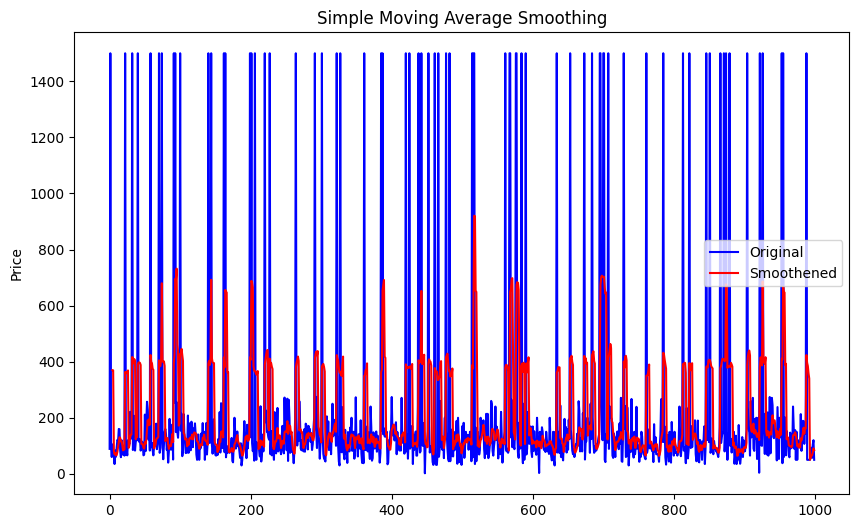

In [ ]:
import matplotlib.pyplot as plt

def simple_moving_avg_smoothing(data, window_size):
    smoothed = []
    for i in range(len(data)):
        if i < window_size - 1:
            smoothed.append(None)  # not enough values yet
        else:
            window = data[i+1-window_size : i+1]
            smoothed.append(sum(window) / window_size)
    return smoothed

price = dataset['Price'].tolist()
smoothened_price = simple_moving_avg_smoothing(price, 5)

print('Before smoothing:\n', price)
print('\nAfter smoothing:\n', smoothened_price)

plt.figure(figsize=(10, 6))
plt.plot(price, label='Original', color='blue')
plt.plot(smoothened_price, label='Smoothened', color='red')
plt.legend()
plt.ylabel('Price')
plt.title('Simple Moving Average Smoothing')
plt.show()

# 7. PCA
Apply PCA on the fields Rating score, Accuracy score, Cleanliness score, Checkin score, Communication score, Location score, Value for money score. Let the new field be called Score and choose PC1.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

cols = ["Rating score", "Accuracy score", "Cleanliness score", "Checkin score", "Communication score", "Location score", "Value for money score"]

# Standardize the columns
scaler = StandardScaler()
scaled = scaler.fit_transform(dataset[cols])

# PCA
pca = PCA(n_components=1)
pc1 = pca.fit_transform(scaled)

dataset["Score"] = pc1
dataset.head()

,46520,Last year reviews,Host since,Host is superhost,Host number of listings,Neighbourhood,Beds number,Bedrooms number,Property type,Maximum allowed guests,...,Value for money score,Reviews per month,City,Season,Bathrooms number,Bathrooms type,Coordinates,Date of scraping,Host Since Bin,Score
0,31840,-0.575775,1970,Host,44,Centro Storico,1,1.0,Private room,2.0,...,4.70,0.78,Firenze,Early Winter,1,private,"43.77709, 11.25216",2024-12-15,Bin3,0.062838
1,222527,-0.849888,1970,Superhost,3,Rifredi,3,2.0,Entire home,4.0,...,4.86,1.92,Firenze,Early Winter,1,private,"43.82005, 11.22004",2024-12-15,Bin3,1.142354
2,32120,-0.575775,1970,Host,1,Gavinana Galluzzo,1,1.0,Entire home,2.0,...,4.63,0.16,Firenze,Summer,1,private,"43.76157, 11.27741",2024-12-15,Bin3,0.471639
3,224562,-0.438718,1970,Host,2,Centro Storico,1,1.0,Entire home,4.0,...,4.64,0.71,Firenze,Early Winter,1,private,"43.772, 11.26142",2024-12-15,Bin3,-0.573394
4,32180,-0.347347,1970,Superhost,1,Centro Storico,4,2.0,Entire home,4.0,...,4.84,0.21,Firenze,Early Winter,2,private,"43.76832, 11.24348",2024-12-15,Bin3,0.015918


# 8. Feature importance
Calculate the feature importance using a decision tree and list down the top 3 features

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   46520                    1000 non-null   int64   
 1   Last year reviews        1000 non-null   float64 
 2   Host since               1000 non-null   int32   
 3   Host is superhost        1000 non-null   object  
 4   Host number of listings  1000 non-null   int64   
 5   Neighbourhood            1000 non-null   object  
 6   Beds number              1000 non-null   int64   
 7   Bedrooms number          1000 non-null   float64 
 8   Property type            1000 non-null   object  
 9   Maximum allowed guests   1000 non-null   float64 
 10  Price                    1000 non-null   float64 
 11  Total reviews            1000 non-null   float64 
 12  Rating score             1000 non-null   float64 
 13  Accuracy score           1000 non-null   float64 
 14  Cleanline

In [ ]:
# To find feature importance of 'Price' using a decision tree and list down the top 3 features

from sklearn.tree import DecisionTreeRegressor

# drop the unusable fields
X = dataset.drop(columns=['Price', 'Host Since Bin', 'Score', '46520', "Coordinates", "Date of scraping"])
y = dataset['Price']

# encode the categorical data
categorical_cols = [
    "Host is superhost", "Neighbourhood", "Property type",
    "City", "Season", "Bathrooms type"
]
X_encoded = pd.get_dummies(X, columns=categorical_cols)

# Finding Feature importance using Decision tree
model = DecisionTreeRegressor(random_state=42)
model.fit(X_encoded, y)

importances = pd.Series(model.feature_importances_, index=X_encoded.columns)
top3 = importances.sort_values(ascending=False).head(3)

print("Top 3 Important Features:")
print(top3)

Top 3 Important Features:
Bathrooms number    0.224209
Location score      0.112751
Accuracy score      0.102155
dtype: float64


# 3. Removing duplicates
a) Using the Listings ID as the key show the duplicates and drop them from the file

In [ ]:
df = dataset.rename(columns={"46520": "Listing_ID"})

df.drop_duplicates(subset="Listing_ID", keep="first", inplace=True)

df

,Listing_ID,Last year reviews,Host since,Host is superhost,Host number of listings,Neighbourhood,Beds number,Bedrooms number,Property type,Maximum allowed guests,...,Value for money score,Reviews per month,City,Season,Bathrooms number,Bathrooms type,Coordinates,Date of scraping,Host Since Bin,Score
0,31840,-0.575775,1970,Host,44,Centro Storico,1,1.0,Private room,2.0,...,4.70,0.78,Firenze,Early Winter,1,private,"43.77709, 11.25216",2024-12-15,Bin3,0.062838
1,222527,-0.849888,1970,Superhost,3,Rifredi,3,2.0,Entire home,4.0,...,4.86,1.92,Firenze,Early Winter,1,private,"43.82005, 11.22004",2024-12-15,Bin3,1.142354
2,32120,-0.575775,1970,Host,1,Gavinana Galluzzo,1,1.0,Entire home,2.0,...,4.63,0.16,Firenze,Summer,1,private,"43.76157, 11.27741",2024-12-15,Bin3,0.471639
3,224562,-0.438718,1970,Host,2,Centro Storico,1,1.0,Entire home,4.0,...,4.64,0.71,Firenze,Early Winter,1,private,"43.772, 11.26142",2024-12-15,Bin3,-0.573394
4,32180,-0.347347,1970,Superhost,1,Centro Storico,4,2.0,Entire home,4.0,...,4.84,0.21,Firenze,Early Winter,2,private,"43.76832, 11.24348",2024-12-15,Bin3,0.015918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,4375536,-0.484404,1970,Superhost,1,Isolotto Legnaia,6,3.0,Entire home,8.0,...,4.87,4.59,Firenze,Early Winter,1,private,"43.77922, 11.213",2024-12-15,Bin3,1.553859
996,4953441,-0.758517,1970,Host,5,Isolotto Legnaia,2,1.0,Private room,3.0,...,4.82,0.60,Firenze,Early Winter,2,shared,"43.77298, 11.22204",2024-12-15,Bin3,1.026824
997,4961760,-0.438718,1970,Superhost,2,Centro Storico,1,1.0,Entire home,2.0,...,4.82,0.18,Firenze,Early Winter,1,private,"43.7642, 11.24754",2024-12-15,Bin3,1.900905
998,4962982,-0.667146,1970,Host,1,Centro Storico,2,1.0,Entire home,4.0,...,4.81,1.93,Firenze,Early Winter,1,private,"43.76985, 11.24981",2024-12-15,Bin3,1.199538
